In [1]:
# imports
import os
import pandas as pd
import numpy as np
import json
import random 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
from TrackReconstruction_functions import *
import sys

In [2]:
file = "/mnt/d/events_45_135/simulated_data/1bar/5.0percent/events_45_135_5.0percent_smear_9.h5"
diffusion = "5.0percent"
pressure = 1
event_type = "events_45_135"
eid = 501

part_df = pd.read_hdf(file, "MC/particles")
hits_df = pd.read_hdf(file, "MC/hits")

part_df.head()

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,501,2,e-,1,0,-1470.519409,-1057.771851,486.927368,0.000000,-1483.967896,...,1.378286,-1.013267,-1.443671,-0.0,-0.0,0.0,1.785017,2403.696533,none,eIoni
1,501,186,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026367,...,-0.004645,0.002265,-0.003056,0.0,0.0,-0.0,0.000035,0.000033,eIoni,msc
2,501,185,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026245,...,0.003945,0.004268,0.001506,-0.0,0.0,0.0,0.000035,0.000280,eIoni,msc
3,501,184,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026611,...,-0.004535,0.003292,0.003553,0.0,0.0,-0.0,0.000043,0.000332,eIoni,msc
4,501,183,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.025269,...,0.002839,0.000641,0.000104,0.0,0.0,0.0,0.000008,0.001171,eIoni,eIoni


In [3]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

### True Data

In [4]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [5]:
vertex = get_vertex(part_df, eid)
print(vertex)

(np.float32(-1470.5194), np.float32(-1057.7719), np.float32(486.92737))


In [6]:
def get_true_angle(part, eid):
    p_x1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_x.iloc[0]
    p_y1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_y.iloc[0]
    p_z1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_z.iloc[0]
    
    p_x2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_x.iloc[0]
    p_y2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_y.iloc[0]
    p_z2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_z.iloc[0]
    
    cos12 = ((p_x1 * p_x2) + (p_y1 * p_y2) + (p_z1 * p_z2))/(np.sqrt((p_x1 ** 2) + (p_y1 ** 2) + (p_z1 ** 2)) * np.sqrt((p_x2 ** 2) + (p_y2 ** 2) + (p_z2 ** 2)))
    return cos12

In [7]:
cos12_true = get_true_angle(part_df, eid)
print(cos12_true)

-0.7766653


In [8]:
def get_true_e_vectors(eid, part_df, vertex, particle_ids=[1,2]):
    vertex = np.array(vertex, dtype=float)
    
    vectors=[]

    for pid in particle_ids:
        row = part_df[(part_df.event_id==eid) & (part_df.particle_id==pid)].iloc[0]

        p = np.array([row.initial_momentum_x, row.initial_momentum_y, row.initial_momentum_z], dtype=float)

        #unit dir
        direction = p / np.linalg.norm(p)

        endpoint = vertex + direction

        vectors.append((endpoint, direction))

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]

    return vectors

In [9]:
vectors = get_true_e_vectors(eid, part_df, vertex)
print(vectors)

[{'endpoint': [-1471.0808077559682, -1057.9659200891856, 487.73183610404453], 'direction': [-0.5613985762807924, -0.19406950324819616, 0.8044679399820094]}, {'endpoint': [-1469.9036711602514, -1058.2245191535885, 486.2824202132309], 'direction': [0.6157380194360083, -0.4526685676509284, -0.6449479508315992]}]


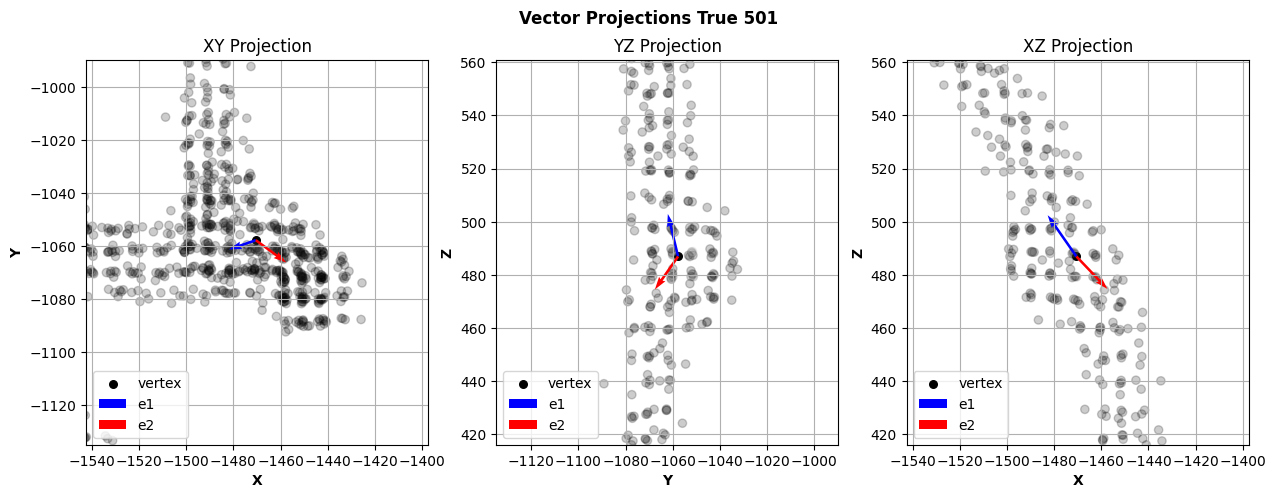

In [10]:
# plot true

x_vertex, y_vertex, z_vertex = vertex[0], vertex[1], vertex[2]
p1, p2 = vectors[0]["direction"], vectors[1]["direction"]

scale_factor = 20  # Adjust this to make arrows longer or shorter

p1 = [scale_factor * comp for comp in p1]
p2 = [scale_factor * comp for comp in p2]


event_hits = hits_df[hits_df.event_id == eid].copy()
event_hits["z"] = event_hits["z"]-z_shift

indices = np.arange(len(event_hits))

# getting axis range
    
xs = [x_vertex, x_vertex + p1[0], x_vertex + p2[0]]
ys = [y_vertex, y_vertex + p1[1], y_vertex + p2[1]]
zs = [z_vertex, z_vertex + p1[2], z_vertex + p2[2]]


#min/max
xmin, xmax = min(xs), max(xs)
ymin, ymax = min(ys), max(ys)
zmin, zmax = min(zs), max(zs)

#ranges = and padded
max_range = max(xmax-xmin, ymax-ymin, zmax-zmin)
pad = 2 * max_range #20% padding

xmid = (xmax + xmin) / 2 
ymid = (ymax + ymin) / 2
zmid = (zmax + zmin) / 2

xlims = (xmid - max_range/2 - pad, xmid + max_range/2 + pad)
ylims = (ymid - max_range/2 - pad, ymid + max_range/2 + pad)
zlims = (zmid - max_range/2 - pad, zmid + max_range/2 + pad)

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

#XY projection
ax1.scatter(x_vertex, y_vertex, color = "black", s=30, label="vertex")
ax1.scatter(event_hits.x, event_hits.y, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax1.quiver(x_vertex, y_vertex, p1[0], p1[1], color="blue", label="e1", scale_units="xy", scale=1)
ax1.quiver(x_vertex, y_vertex, p2[0], p2[1], color="red", label="e2", scale_units="xy", scale=1)
ax1.set_xlim(xlims)
ax1.set_ylim(ylims)
ax1.set_xlabel("X", fontweight="bold")
ax1.set_ylabel("Y", fontweight="bold")
ax1.set_title("XY Projection")
ax1.legend(loc="lower left")
ax1.grid(True)
    
#YZ projection
ax2.scatter(y_vertex, z_vertex, color = "black", s=30, label="vertex")
ax2.scatter(event_hits.y, event_hits.z, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax2.quiver(y_vertex, z_vertex, p1[1], p1[2], color="blue", label="e1", scale_units="xy", scale=1)
ax2.quiver(y_vertex, z_vertex, p2[1], p2[2], color="red", label="e2", scale_units="xy", scale=1)
ax2.set_xlim(ylims)
ax2.set_ylim(zlims)
ax2.set_xlabel("Y", fontweight="bold")
ax2.set_ylabel("Z", fontweight="bold")
ax2.set_title("YZ Projection")
ax2.legend(loc="lower left")
ax2.grid(True)

#XZ projection
ax3.scatter(x_vertex, z_vertex, color = "black", s=30, label="vertex")
ax3.scatter(event_hits.x, event_hits.z, alpha=0.2, c=event_hits.energy, cmap="Greys_r")
ax3.quiver(x_vertex, z_vertex, p1[0], p1[2], color="blue", label="e1", scale_units="xy", scale=1)
ax3.quiver(x_vertex, z_vertex, p2[0], p2[2], color="red", label="e2", scale_units="xy", scale=1)
ax3.set_xlim(xlims)
ax3.set_ylim(zlims)
ax3.set_xlabel("X", fontweight="bold")
ax3.set_ylabel("Z", fontweight="bold")
ax3.set_title("XZ Projection")
ax3.legend(loc="lower left")
ax3.grid(True)

fig.suptitle(f"Vector Projections True {eid}", fontweight="bold")

plt.show()

### Reco Data (From True Vertex)

In [11]:
def get_node_centers_df(hits_df, eid, pressure, diffusion, diff_scale_change):
    print(f"diffusion: {diffusion}")
    print(f"pressure: {pressure}")
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    #print(pressure, type(pressure))
    #print(diffusion, type(diffusion))
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)
    # voxel_sf=1.1
    # energy_threshold=0
    # energy_threshold = 0.0004
    diff_scale_factor = diff_scale_change
    print("Diffussion smear is: ",        Diff_smear,            "mm/sqrt(cm)")
    print("Energy threshold is: ",        1000*energy_threshold, "keV")
    print("diffision scale factor is: ",  diff_scale_factor)
    print("Radius scale factor is: ",     radius_sf)
    print("Hit grouping factor is: ",     group_sf)
    print("Tortuosity distance scale is:", Tortuosity_dist)
    print("The voxel size is:",           voxel_size)
    print("The det_size is", det_size)
    
    #print(f"diffusion: {diffusion}")
    if (diffusion == "next1t"):
        mean_sigma=6
    elif (diffusion == "nodiff"):
        #print(f"check diffusion: {diffusion}")
        mean_sigma=10/np.sqrt(pressure)
        #print(f"check mean sigma: {mean_sigma}")
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    """
    print(f"xmin: {xmin}, xmax: {xmax}, xbw: {xbw}")
    print(f"ymin: {ymin}, ymax: {ymax}, ybw: {ybw}")
    print(f"zmin: {zmin}, zmax: {zmax}, zbw: {zbw}")
    
    print(f"data x range: {data['x'].min()} to {data['x'].max()}")
    print(f"data y range: {data['y'].min()} to {data['y'].max()}")
    print(f"data z range: {data['z'].min()} to {data['z'].max()}")
    """
    # Apply grouping
    data_copy = data.copy()
    #df_merged = CutandRedistibuteEnergy(data_copy, energy_threshold)

    
    
    if diffusion == "next1t":
        mean_sigma_group = 10
    elif (diffusion == "nodiff"):
        #print(f"diffusion: {diffusion}")
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0
        """
    print("Mean sigma group", mean_sigma_group)
    print("Number of hits:", len(data))
    print("Mean z:", data.z.mean(), " diffusion = ", mean_sigma)
    print("Mean Sigma: ", mean_sigma)
    """
    #print("Mean sigma group:", mean_sigma_group)

    
    df_merged = GroupHits(data_copy, mean_sigma_group)
    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    for gid in sorted(df_merged.group_id.unique()):
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]
    return node_centers_df


In [21]:
def get_reco_e_vectors(hits_df, part_df, eid, N, diffusion, pressure, z_shift, diff_scale_change, vertex=None, plot=False):

    node_centers_df = get_node_centers_df(hits_df, eid, pressure, diffusion, diff_scale_change)
    df = node_centers_df.copy() 
    df["z"] = df["z"] - z_shift
    
    if vertex is None:
        vertex = get_vertex(part_df, eid)
    else:
        vertex = vertex
        
    hits = df[["x", "y", "z"]].values
    
    dists = np.linalg.norm(hits - vertex, axis=1) 
    N=N #cluster hits total
    closest_hits = hits[np.argsort(dists)[:N]] # sort by dist
    hits_from_vertex = closest_hits - vertex # use vertex as reference
    radii = np.linalg.norm(hits_from_vertex, axis=1)

    # keep only hits that are not at the vertex
    mask = radii > 10 #events <1mm from vertex are not used
    hits_from_vertex = hits_from_vertex[mask]
    closest_hits = closest_hits[mask]
    radii = radii[mask]

    if len(radii)<2:
        #print("Not enough hits to cluster")
        return[]
    # normalize
    directions = hits_from_vertex / radii[:, None]
    
    kmeans = KMeans(n_clusters=2, random_state=0).fit(directions) # 2 clusters
    labels = kmeans.labels_
    
    vectors = []
    for cluster_id in [0,1]:
        cluster_hits = closest_hits[labels == cluster_id] #cluster hits
    
        if len(cluster_hits) == 0:
            #print("Not enough hits")
            continue
            
        #get vectors
        dists = np.linalg.norm(cluster_hits - vertex, axis=1) 
        endpoint = cluster_hits[np.argmin(dists)]
        direction_vector = endpoint - vertex
        vectors.append((endpoint, direction_vector))

    event_hits = hits_df[hits_df.event_id == eid]

    # plot clustered hits
    if plot == True:
        vertex_true = get_vertex(part_df, eid)
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")
        part_1 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 1)]
        part_2 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 2)]
    
        p1 = part_1[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()
        p2 = part_2[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()    
        colors = ["red", "blue"]
            
        for cluster_id in [0, 1]:
            cluster_hits = closest_hits[labels == cluster_id]
            ax.scatter(cluster_hits[:, 0], cluster_hits[:, 1], cluster_hits[:, 2],
                           label=f"Cluster {cluster_id}", color=colors[cluster_id], s=40)
    
        ax.scatter(vertex[0], vertex[1], vertex[2], color="black", s=60, label="Vertex Smeared")
        ax.scatter(vertex_true[0], vertex_true[1], vertex_true[2], color="green", s=60, label="Vertex")
            #ax.scatter(event_hits["x"], event_hits["y"], event_hits["z"], color="black", alpha=0.1, s=30)
        ax.scatter(df["x"], df["y"], df["z"], color="purple", marker="+", alpha=0.5)
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[0][1][0], vectors[0][1][1], vectors[0][1][2], label="reco", color="black")
        ax.quiver(vertex[0], vertex[1], vertex[2], vectors[1][1][0], vectors[1][1][1], vectors[1][1][2], color="black")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p1[0], p1[1], p1[2], length=10, label="true", color="purple")
        ax.quiver(vertex_true[0], vertex_true[1], vertex_true[2], p2[0], p2[1], p2[2], length=10, color="purple")
        ax.legend()
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_xlim((vertex[0] - 50), (vertex[0] + 50))
        ax.set_ylim((vertex[1] - 50), (vertex[1] + 50))
        ax.set_zlim((vertex[2] - 50), (vertex[2] + 50))
        ax.set_title("KMeans Clustering of Hits")
    
        plt.show()

    vectors = [
        {"endpoint": vec[0].tolist(), "direction": vec[1].tolist()}
        for vec in vectors
        ]
    
    return vectors

diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  8
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764


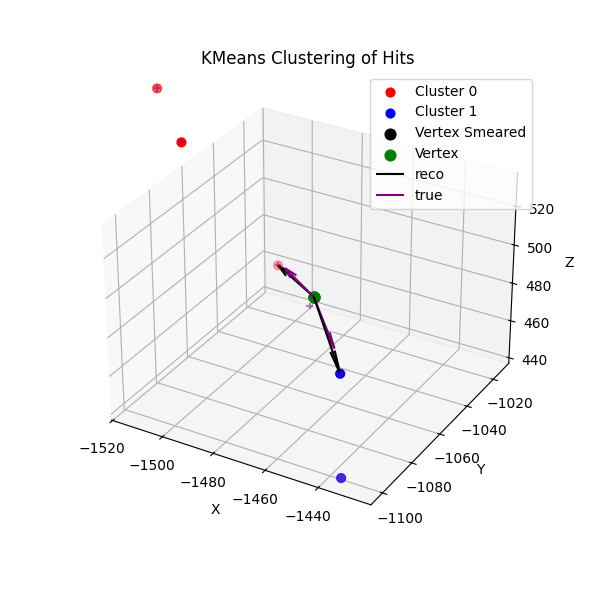

[(array([-1484.03344727, -1058.41479492,   498.48428961]),
  array([-13.51403809,  -0.64294434,  11.55692145])),
 (array([-1452.71252441, -1071.0135498 ,   463.16910407]),
  array([ 17.80688477, -13.24169922, -23.7582641 ]))]

In [13]:
%matplotlib widget
get_reco_e_vectors(hits_df, part_df, eid, 10, "5.0percent", pressure, z_shift, 8, vertex=vertex, plot=True)


In [14]:
def get_true_angle(eid, part):
    p_x1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_x.iloc[0]
    p_y1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_y.iloc[0]
    p_z1 = part[(part.event_id == eid) & (part.particle_id == 1)].initial_momentum_z.iloc[0]
    
    p_x2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_x.iloc[0]
    p_y2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_y.iloc[0]
    p_z2 = part[(part.event_id == eid) & (part.particle_id == 2)].initial_momentum_z.iloc[0]
    
    cos12 = ((p_x1 * p_x2) + (p_y1 * p_y2) + (p_z1 * p_z2))/(np.sqrt((p_x1 ** 2) + (p_y1 ** 2) + (p_z1 ** 2)) * np.sqrt((p_x2 ** 2) + (p_y2 ** 2) + (p_z2 ** 2)))
    return cos12

In [15]:
angle_diff_5 = []
angle_diff_6 = []
angle_diff_7 = []
angle_diff_8 = []
angle_diff_9 = []
angle_diff_lists = [angle_diff_5, angle_diff_6, angle_diff_7, angle_diff_8, angle_diff_9]
for eid, data in part_df.groupby("event_id"):
    print(f"Starting event: {eid}")
    vertex = get_vertex(part_df, eid)
    vectors_true = get_true_e_vectors(eid, part_df, vertex, particle_ids=[1,2])
    cos12_true = get_true_angle(eid, part_df)
    for i in range(5,10):
        vectors_reco = get_reco_e_vectors(hits_df, part_df, eid, 10, diffusion, pressure, z_shift, i, vertex=None, plot=False)
        v1 = vectors_reco[0][1]
        v2 = vectors_reco[1][1]
        cos12_reco = np.dot(v1, v2)/(np.linalg.norm(v1) * np.linalg.norm(v2))
        angle_diff = cos12_true - cos12_reco
        angle_diff_lists[i - 5].append(cos12_true - cos12_reco)
    
    

Starting event: 501
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  5
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  6
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  7
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  8
Radius sc

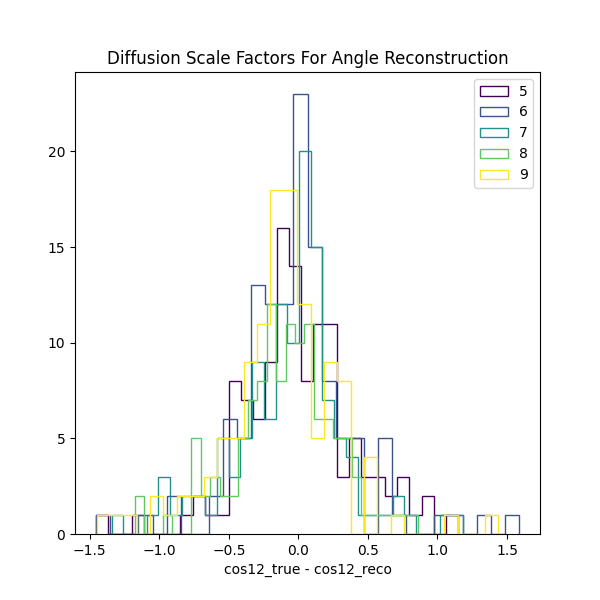

In [16]:
plt.figure(figsize=(6,6))

cmap = plt.get_cmap('viridis')
colors = [cmap(x) for x in np.linspace(0, 1, len(angle_diff_lists))]

for i, data in enumerate(angle_diff_lists):
    plt.hist(data, bins=30, color=colors[i], histtype="step", label=f"{i+5}")

plt.title("Diffusion Scale Factors For Angle Reconstruction")
plt.xlabel("cos12_true - cos12_reco")

plt.legend()

### Reco Data (From Smeared Vertex)

In [17]:
def add_smear(part_df, eid, smear):
    vertex = get_vertex(part_df, eid)
        
    phi = np.random.uniform(0, 2*np.pi)
    costheta = np.random.uniform(-1, 1)
    theta = np.arccos(costheta)
                    
    r = smear
    
    x_new = vertex[0] + r * np.sin(theta) * np.cos(phi)
    y_new = vertex[1] + r * np.sin(theta) * np.sin(phi)
    z_new = vertex[2] + r * np.cos(theta)
    
    vertex_smeared = np.array([x_new, y_new, z_new])

    return vertex_smeared

In [24]:
eid = 501

vertex = get_vertex(part_df, eid)
cos12_true = get_true_angle(eid, part_df)
vectors = get_true_e_vectors(eid, part_df, vertex)
vectors_reco = get_reco_e_vectors(hits_df, part_df, eid, 10, diffusion, pressure, z_shift, 6, vertex=None, plot=False)
rv1 = vectors_reco[0]["direction"]
rv2 = vectors_reco[1]["direction"]
cos12_reco = np.dot(rv1, rv2)/(np.linalg.norm(rv1) * np.linalg.norm(rv2))

for smear in range(1, 6):
    vertex_smeared = add_smear(part_df, eid, smear)
    vectors_smeared = get_reco_e_vectors(hits_df, part_df, eid, 10, diffusion, pressure, z_shift, 6, vertex=vertex_smeared, plot=False)
    sv1 = vectors_smeared[0]["direction"]
    sv2 = vectors_smeared[1]["direction"]
    cos12_smeared = np.dot(sv1, sv2)/(np.linalg.norm(sv1) * np.linalg.norm(sv2))
    print(cos12_smeared)

diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  6
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  6
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
-0.4972123988101901
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale factor is:  6
Radius scale factor is:  7
Hit grouping factor is:  5
Tortuosity distance scale is: 105.0
The voxel size is: 8
The det_size is 3091.169274839764
0.013974649637335334
diffusion: 5.0percent
pressure: 1
Diffussion smear is:  0.314 mm/sqrt(cm)
Energy threshold is:  0.3 keV
diffision scale fa

In [23]:
file = "/mnt/d/events_45_135/simulated_data/1bar/5.0percent/events_45_135_5.0percent_smear_991.h5"
part_df = pd.read_hdf(file, "MC/particles")
part_df.head()

,event_id,particle_id,particle_name,primary,mother_id,initial_x,initial_y,initial_z,initial_t,final_x,...,initial_momentum_x,initial_momentum_y,initial_momentum_z,final_momentum_x,final_momentum_y,final_momentum_z,kin_energy,length,creator_proc,final_proc
0,501,2,e-,1,0,-1470.519409,-1057.771851,486.927368,0.000000,-1483.967896,...,1.378286,-1.013267,-1.443671,-0.0,-0.0,0.0,1.785017,2403.696533,none,eIoni
1,501,186,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026367,...,-0.004645,0.002265,-0.003056,0.0,0.0,-0.0,0.000035,0.000033,eIoni,msc
2,501,185,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026245,...,0.003945,0.004268,0.001506,-0.0,0.0,0.0,0.000035,0.000280,eIoni,msc
3,501,184,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.026611,...,-0.004535,0.003292,0.003553,0.0,0.0,-0.0,0.000043,0.000332,eIoni,msc
4,501,183,e-,0,2,-1484.026367,-523.301880,-648.665039,8.925844,-1484.025269,...,0.002839,0.000641,0.000104,0.0,0.0,0.0,0.000008,0.001171,eIoni,eIoni
